# Subagents

In the **subagents** architecture, a central main `agent` (often referred to as a **supervisor**) coordinates subagents by calling them as `tools`. 

The main agent decides which subagent to invoke, what input to provide, and how to combine results. Subagents are stateless — they don't remember past interactions, with all conversation memory maintained by the main agent. 

This provides `context` isolation: each subagent invocation works in a clean context window, preventing context bloat in the main conversation.

![alt text](./agent-subagents.png)

## Key characteristics

* Centralized control: All routing passes through the main agent
* No direct user interaction: Subagents return results to the main agent, not the user
* Subagents via tools: Subagents are invoked via tools
* Parallel execution: The main agent can invoke multiple subagents in a single turn

<Note>

  **Supervisor vs. Router**: A supervisor agent (this pattern) is different from a `router`. The supervisor is a full agent that maintains conversation context and dynamically decides which subagents to call across multiple turns. A router is typically a single classification step that dispatches to agents without maintaining ongoing conversation state.
</Note>

## When to use

Use the subagents pattern when you have multiple distinct domains (e.g., calendar, email, CRM, database), subagents don't need to converse directly with users, or you want centralized workflow control. For simpler cases with just a _few tools_, use a `single agent`.

<Tip>

  **Need user interaction within a subagent?** While subagents typically return results to the main agent rather than conversing directly with users, you can use `interrupts` ( or **human-in-the-loop**) within a subagent to pause execution and gather user input. This is useful when a subagent needs clarification or approval before proceeding. The main agent remains the orchestrator, but the subagent can collect information from the user mid-task.
</Tip>


In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchResults

# Create a subagent with search tool
@tool()
def duckduckgo_search(query: str):
    """Perform a web search using DuckDuckGo."""
    search = DuckDuckGoSearchResults(num_results=3)
    results = search.invoke(query)
    # DuckDuckGo returns a string, just return it directly
    return results
subagent = create_agent(
    model="ollama:granite4:3b", 
    tools=[duckduckgo_search],
    system_prompt="You are a research assistant. Use the search tool to find relevant information.")

# Wrap it as a tool
@tool("research", description="Research a topic and return findings")
def call_research_agent(query: str):
    result = subagent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

# Main agent with subagent as a tool
main_agent = create_agent(
    model="openai:gpt-5.2", 
    tools=[call_research_agent],
    system_prompt="You are an AI supervisor agent that coordinates research subagents.")

query = "What are pros & cons of MCP tools usage?"
for step in main_agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

    

================================ Human Message =================================

What are pros & cons of MCP tools usage?
================================== Ai Message ==================================
Tool Calls:
  research (call_YUNcTXKGqEkpVqrWbuuq2I76)
 Call ID: call_YUNcTXKGqEkpVqrWbuuq2I76
  Args:
    query: Model Context Protocol MCP tools pros cons usage security latency governance
  research (call_JPVl0GcBdnWNp2kaXTi02C9X)
 Call ID: call_JPVl0GcBdnWNp2kaXTi02C9X
  Args:
    query: common pitfalls of MCP tool usage prompt injection data exfiltration least privilege
  research (call_kNjBaJ90lFXzJ8y1JyXqjG1I)
 Call ID: call_kNjBaJ90lFXzJ8y1JyXqjG1I
  Args:
    query: benefits of MCP standardization interoperability tool discovery schema
  research (call_h68NSxoEE05KAEjeI7Re1TAv)
 Call ID: call_h68NSxoEE05KAEjeI7Re1TAv
  Args:
    query: operational considerations MCP servers versioning auth observability
================================= Tool Message ===========================

'main_agent'

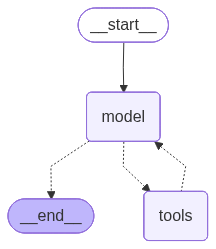

'subagent'

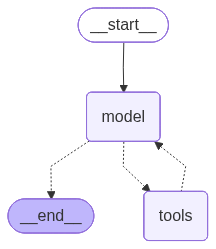

In [3]:
from IPython.display import display, Image
display("main_agent",Image(main_agent.get_graph(xray=True).draw_mermaid_png()))   
display("subagent",Image(subagent.get_graph(xray=True).draw_mermaid_png()))   

In [1]:
"""
Personal Assistant Supervisor Example

This example demonstrates the tool calling pattern for multi-agent systems.
A supervisor agent coordinates specialized sub-agents (calendar and email)
that are wrapped as tools.
"""

from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
import json
from IPython.display import display, Image
from dataclasses import dataclass

@dataclass
class RuntimeContext:
    user_id: str = ""
    user_name: str = "anonymous"
    user_email: str = ""
    user_role: str = "guest"  # admin, contributor, viewer, guest
    user_preferences: dict = None
    def __str__(self):
        return json.dumps(self.__dict__, indent=2)

#mock user data, e.g. from SSO
def _create_context() -> RuntimeContext:
    return RuntimeContext(
        user_id="001",
        user_name="Alice Johnson",
        user_email="alice.johnson@example.com",
        user_preferences={"theme": "dark", "language": "en"}
    )
RUNTIME_CONTEXT = _create_context()

# define models
model_agent = ChatOllama(model="gpt-oss:20b", temperature=0, reasoning=True)
model_supervisor = ChatOpenAI(model="gpt-5.2", temperature=0, reasoning_effort='low')

# ============================================================================
# Step 1: Define low-level API tools (stubbed)
# ============================================================================

@tool
def get_user_info(runtime: ToolRuntime[RuntimeContext]) -> str:
    """Returns user info from the context."""
    return str(runtime.context)
@tool
def get_current_date_time() -> str:
    """Returns current date & time. Useful for scheduling."""
    from datetime import datetime
    return datetime.now().isoformat()
@tool
def create_calendar_event(
    title: str,
    start_time: str,  # ISO format: "2024-01-15T14:00:00"
    end_time: str,    # ISO format: "2024-01-15T15:00:00"
    attendees: list[str],  # email addresses
    location: str = ""
) -> str:
    """Create a calendar event. Requires exact ISO datetime format."""
    id  = "evt_" + str(abs(hash(title + start_time)))  # mock event ID
    return f"Event id `{id}` created: {title} from {start_time} to {end_time} with {len(attendees)} attendees"

@tool
def delete_calendar_event(event_id: str) -> str:
    """Delete a calendar event by ID."""
    return f"Event {event_id} deleted"


@tool
def send_email(
    to: list[str],      # email addresses
    subject: str,
    body: str,
    cc: list[str] = []
) -> str:
    """Send an email via email API. Requires properly formatted addresses."""
    print(f"Sending email to: {to}, cc: {cc}, subject: {subject}", f"body: {body}")
    return f"Email sent to {', '.join(to)} - Subject: {subject} - Body: {body}"


@tool
def get_available_time_slots(
    attendees: list[str],
    date: str,  # ISO format: "2024-01-15"
    duration_minutes: int
) -> list[str]:
    """Check calendar availability for given attendees on a specific date."""
    return ["09:00", "14:00", "16:00"]


# ============================================================================
# Step 2: Create specialized sub-agents
# ============================================================================
CALENDAR_AGENT_PROMPT = (
    "You are a calendar scheduling assistant. "
    "Parse natural language scheduling requests (e.g., 'next Tuesday at 2pm') "
    "into proper ISO datetime formats, ALWAYS use get_current_date_time tool to resolve relative dates into absolute dates (year-month-day). "
    "Use get_available_time_slots to check availability when needed. "
    "Use create_calendar_event to schedule events. "
    "Always confirm what was scheduled in your final response."
)
calendar_agent = create_agent(
    model_agent,
    tools=[create_calendar_event, delete_calendar_event, get_available_time_slots, get_current_date_time],
    system_prompt=CALENDAR_AGENT_PROMPT
)

EMAIL_AGENT_PROMPT = (
        "You are an email assistant. "
        "Compose professional emails based on natural language requests. "
        "Extract recipient information and craft appropriate subject lines and body text. "
        "Use send_email to send the message. "
        "Always confirm what was sent in your final response."
    )
email_agent = create_agent(
    model_agent,
    tools=[send_email],
        system_prompt=EMAIL_AGENT_PROMPT
)

# ============================================================================
# Step 3: Wrap sub-agents as tools for the supervisor
# ============================================================================

@tool
def schedule_event(request: str) -> str:
    """Schedule calendar events using natural language.

    Use this when the user wants to create, modify, or check calendar appointments.
    Handles date/time parsing, availability checking, and event creation.

    Input: Natural language scheduling request (e.g., 'meeting with design team
    next Tuesday at 2pm')
    """
    result = calendar_agent.invoke({
        "messages": [{"role": "user", "content": request}]
    })
    return result["messages"][-1].text


@tool
def manage_email(request: str) -> str:
    """Send emails using natural language.

    Use this when the user wants to send notifications, reminders, or any email
    communication. Handles recipient extraction, subject generation, and email
    composition.

    Input: Natural language email request (e.g., 'send them a reminder about
    the meeting')
    """
    result = email_agent.invoke({
        "messages": [{"role": "user", "content": request}]
    })
    return result["messages"][-1].text


# ============================================================================
# Step 4: Create the supervisor agent
# ============================================================================
SUPERVISOR_PROMPT = (
    "You are a helpful personal assistant. "
    "You can schedule calendar events and send emails. "
    "When scheduling, ensure to provide proper date & time, available via get_current_date_time tool. "
    "User info is provided via available tools. First, always try to identify user. "
    "Break down user requests into appropriate tool calls and coordinate the results. "
    "When a request involves multiple actions, use multiple tools in sequence."
)
supervisor_agent = create_agent(
    model_supervisor,
    tools=[schedule_event, manage_email, get_user_info, get_current_date_time],
    context_schema=RuntimeContext,    
    system_prompt=SUPERVISOR_PROMPT
)

# ============================================================================
# Step 5: Use the supervisor
# ============================================================================

# Example: User request requiring both calendar and email coordination
user_request = (
    "Schedule a meeting with the design team next Tuesday at 2pm for 1 hour, "
    "then send me an email reminder with meeting details."
)

print("User Request:", user_request)
print("\n" + "="*80 + "\n")

for step in supervisor_agent.stream(
    {"messages": [{"role": "user", "content": user_request}]},
    context=RUNTIME_CONTEXT,
):
    for update in step.values():
        for message in update.get("messages", []):
            message.pretty_print()

User Request: Schedule a meeting with the design team next Tuesday at 2pm for 1 hour, then send me an email reminder with meeting details.


================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_ujTBVvteaP4FXq9SQT1OXZv4)
 Call ID: call_ujTBVvteaP4FXq9SQT1OXZv4
  Args:
  get_current_date_time (call_y4ua8tt47jVvMDk4eNMLxbuP)
 Call ID: call_y4ua8tt47jVvMDk4eNMLxbuP
  Args:
================================= Tool Message =================================
Name: get_user_info

{
  "user_id": "001",
  "user_name": "Alice Johnson",
  "user_email": "alice.johnson@example.com",
  "user_role": "guest",
  "user_preferences": {
    "theme": "dark",
    "language": "en"
  }
}
================================= Tool Message =================================
Name: get_current_date_time

2026-01-07T11:59:32.989093
================================== Ai Message ==================================
Tool Calls:
  schedule_event (call_sa39UXN9d7u8LwgX

In [2]:
# interrupt with human-in-the-loop
from langchain.agents.middleware import HumanInTheLoopMiddleware 
from langgraph.checkpoint.memory import InMemorySaver 

# edit calendar agent to include human-in-the-loop for deletions
calendar_agent = create_agent(
    model_agent,
    tools=[create_calendar_event, delete_calendar_event, get_available_time_slots, get_current_date_time],
    system_prompt=CALENDAR_AGENT_PROMPT,
    middleware=[HumanInTheLoopMiddleware(
        interrupt_on={delete_calendar_event.name: True}, 
        description_prefix="Calendar event deletion pending approval.")
        ]    
)

# add memory saver to supervisor agent
supervisor_agent = create_agent(
    model_supervisor,
    tools=[schedule_event, manage_email, get_user_info, get_current_date_time],
    context_schema=RuntimeContext,    
    system_prompt=SUPERVISOR_PROMPT,
    checkpointer=InMemorySaver()
)
config = {"configurable": {"thread_id": str(abs(hash("personal_assistant_supervisor")))}}

# Example: User request requiring both calendar and email coordination
user_request = (
    "Delete scheduled meeting (id evt_3992A-2026), "
    "then send me a confirmation email."
)

print("User Request:", user_request)
print("\n" + "="*80 + "\n")

interrupts = []
for step in supervisor_agent.stream(
    {"messages": [{"role": "user", "content": user_request}]},
    config=config, #add config for memory
    context=RUNTIME_CONTEXT,
):
    for update in step.values():
        if isinstance(update, dict):
            for message in update.get("messages", []):
                message.pretty_print()
        else:
            interrupt_ = update[0]
            interrupts.append(interrupt_)
            for request in interrupt_.value["action_requests"]:
                    print(f"INTERRUPTED: {interrupt_.id}")
                    print(f"{request['description']}\n")            

User Request: Delete scheduled meeting (id evt_3992A-2026), then send me a confirmation email.


================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_tztMVZSjyp1zstRwW9Py1UpI)
 Call ID: call_tztMVZSjyp1zstRwW9Py1UpI
  Args:
  schedule_event (call_CK1M7EQ1sXMvKDilJQPwtK13)
 Call ID: call_CK1M7EQ1sXMvKDilJQPwtK13
  Args:
    request: Delete/cancel the scheduled meeting with event id evt_3992A-2026.
================================= Tool Message =================================
Name: get_user_info

{
  "user_id": "001",
  "user_name": "Alice Johnson",
  "user_email": "alice.johnson@example.com",
  "user_role": "guest",
  "user_preferences": {
    "theme": "dark",
    "language": "en"
  }
}
INTERRUPTED: b02651bb81040f0072a5855bb1be0d55
Calendar event deletion pending approval.

Tool: delete_calendar_event
Args: {'event_id': 'evt_3992A-2026'}



In [3]:
for interrupt_ in interrupts:
    print(f"\nINTERRUPT: {interrupt_.id}")                    
    print(json.dumps(interrupt_.value, indent=2)) 


INTERRUPT: b02651bb81040f0072a5855bb1be0d55
{
  "action_requests": [
    {
      "name": "delete_calendar_event",
      "args": {
        "event_id": "evt_3992A-2026"
      },
      "description": "Calendar event deletion pending approval.\n\nTool: delete_calendar_event\nArgs: {'event_id': 'evt_3992A-2026'}"
    }
  ],
  "review_configs": [
    {
      "action_name": "delete_calendar_event",
      "allowed_decisions": [
        "approve",
        "edit",
        "reject"
      ]
    }
  ]
}


In [4]:
from langgraph.types import Command 

resume = {}
for interrupt_ in interrupts:
    # Ask the user for confirmation
    print(f"\nResolve interruption {interrupt_.id}: {interrupt_.value['action_requests'][0]['description']}\n")
    user_input = input("([a]accept/cancel): ").strip().lower()
    
    if user_input in ['accept', 'a', 'yes', 'y', '']:
        print(f"✓ Accepted by user")
        decision = "approve"
    else:
        # User declined
        print(f"✗ Cancelled by user")
        decision = "reject"
    resume[interrupt_.id] = {"decisions": [{"type": decision}]}

interrupts = []
for step in supervisor_agent.stream(
    Command(resume=resume), 
    config,
):
    for update in step.values():
        if isinstance(update, dict):
            for message in update.get("messages", []):
                message.pretty_print()
        else:
            interrupt_ = update[0]
            interrupts.append(interrupt_)
            print(f"\nINTERRUPTED: {interrupt_.id}")



Resolve interruption b02651bb81040f0072a5855bb1be0d55: Calendar event deletion pending approval.

Tool: delete_calendar_event
Args: {'event_id': 'evt_3992A-2026'}

✓ Accepted by user
================================= Tool Message =================================
Name: get_user_info

{
  "user_id": "001",
  "user_name": "Alice Johnson",
  "user_email": "alice.johnson@example.com",
  "user_role": "guest",
  "user_preferences": {
    "theme": "dark",
    "language": "en"
  }
}
================================= Tool Message =================================
Name: schedule_event

✅ The meeting with event ID **evt_3992A-2026** has been successfully deleted. If you need to schedule a new meeting or have any other requests, just let me know!
================================== Ai Message ==================================
Tool Calls:
  manage_email (call_m4QkM6suljHOkkg59HiFL0gC)
 Call ID: call_m4QkM6suljHOkkg59HiFL0gC
  Args:
    request: Send a confirmation email to Alice Johnson (alice.joh

In [ ]:
# pass additional context to sub agents, like message history, or runtime context
from langchain.tools import tool, ToolRuntime

@tool
def schedule_event(
    request: str,
    runtime: ToolRuntime
) -> str:
    """Schedule calendar events using natural language."""
    # Customize context received by sub-agent
    original_user_message = next(
        message for message in runtime.state["messages"]
        if message.type == "human"
    )
    prompt = (
        "You are assisting with the following user inquiry:\n\n"
        f"{original_user_message.text}\n\n"
        "You are tasked with the following sub-request:\n\n"
        f"{request}"
    )
    result = calendar_agent.invoke({
        "messages": [{"role": "user", "content": prompt}],
    })
    return result["messages"][-1].text